# Dark Pattern Detector — Notebook 1: Data, NLP & EDA

to build a clean, balanced dataset of NLP features

Steps :
1. load the Yada -2022 dark-pattern dataset.
2. remap the 7 academic categories onto India's 13 CCPA dark-pattern types.
3. load the kaggle dataset.
4. merge everything and de-duplicate so every row is a unique string.
5. nlp preprocessing (clean + lemmatize).
6. build 22 features per row.
7. EDA
8. save the processed dataset.

## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import random

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from textblob import TextBlob

random.seed(42)

In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /Users/abhigoyal/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/abhigoyal/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/abhigoyal/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/abhigoyal/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/abhigoyal/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/abhigoyal/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

## 2. load the yada et al. 2022

In [4]:
# e-commerce dark-pattern data (text + 7 categories)
df_raw = pd.read_csv('../data/raw/dataset_raw.tsv', sep='\t', on_bad_lines='skip', engine='python')
df_raw.head()

,page_id,text,label,Pattern Category
0,1012,FLASH SALE | LIMITED TIME ONLY Shop Now,1,Urgency
1,158,Pillowcases & Shams,0,Not Dark Pattern
2,108,Write a review,0,Not Dark Pattern
3,1425,"To start your return, simply click on the foll...",0,Not Dark Pattern
4,1658,newsletter signup (privacy policy),0,Not Dark Pattern


In [8]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   page_id           2356 non-null   int64
 1   text              2356 non-null   str  
 2   label             2356 non-null   int64
 3   Pattern Category  2356 non-null   str  
dtypes: int64(2), str(2)
memory usage: 202.9 KB


## 3. Map Academic Categories to the 13 CCPA Types

The dataset uses the 2019 paper taxonomy (Urgency, Sneaking, Misdirection...).
India's CCPA (2023) defines 13 legally named dark patterns. We map these onto that.

In [11]:
def map_to_ccpa(cat, text):
    text = str(text).lower()
    if cat == 'Not Dark Pattern':      return 'Not a Dark Pattern'

    if cat in ['Urgency', 'Scarcity']: return 'False Urgency'

    if cat == 'Social Proof':          return 'Disguised Advertisement'

    if cat == 'Misdirection':
        if any(p in text for p in ['no thanks', "i don't want", 'prefer to pay', 'hate saving', 'i prefer']):
            return 'Confirm Shaming'
        
        if any(p in text for p in ['?', 'yes,', 'no,', 'opt-in', 'uncheck', 'pre-checked']):
            return 'Trick Question'
        
        return 'Interface Interference'
    
    if cat == 'Obstruction':
        if any(p in text for p in ['cancel', 'membership', 'subscription', 'renew', 'bill', 'fee', 'hotline']):
            return 'Subscription Trap'
        
        return 'Interface Interference'
    
    if cat == 'Sneaking':
        if any(p in text for p in ['fee', 'charge', 'tax', 'cost', 'surcharge', 'processing', 'booking']):
            return 'Drip Pricing'
        
        return 'Basket Sneaking'
    
    if cat == 'Forced Action':
        return 'Forced Action'
    
    return 'Not a Dark Pattern'

In [ ]:
# apply the mapping 
df_raw['Pattern Category'] = df_raw.apply(lambda r: map_to_ccpa(r['Pattern Category'], r['text']), axis=1)

# add a binary "is this a dark pattern?" label
df_raw['label'] = (df_raw['Pattern Category'] != 'Not a Dark Pattern').astype(int)

df_raw['Pattern Category'].value_counts()

Pattern Category
Not a Dark Pattern         1178
False Urgency               628
Disguised Advertisement     312
Confirm Shaming             105
Interface Interference       65
Trick Question               27
Subscription Trap            25
Basket Sneaking               6
Drip Pricing                  6
Forced Action                 4
Name: count, dtype: int64

## 4. Load another dataset form Kaggle

Yada-2022 is skewed toward *Not a Dark Pattern* and is missing several CCPA categories
entirely (Nagging, SaaS Billing, Rogue Malware, Bait and Switch, Drip Pricing...). To
cover them we got another dataset from kaggle from real e-commerce, SaaS and mobile
apps and grouped them by CCPA category, also good for indian context.

Scraped strings carry specific brand, product and price names, so we normalise those into
placeholder tokens and record the natural wording variations of each collected pattern.
We keep only **unique** strings (duplicates are removed in the next step), which mirrors
how the same dark pattern shows up with small wording changes across different brands.

In [17]:
df2=pd.read_csv('../data/raw/pattern_label.csv')

## 5. Merge and De-duplicate

In [19]:
# Stack the Yada  and kaggle rows together
df = pd.concat([df_raw, df2], ignore_index=True)
df['text'] = df['text'].astype(str).str.strip()
df = df[df['text'].str.len() >= 3]
df.shape

(7192, 5)

In [26]:
df.sample(5)

,page_id,text,label,Pattern Category,Unnamed: 0,_key
3834,ext_21206,Trending story: how I saved big shopping on Ph...,1,Disguised Advertisement,1478.0,trending story how i saved big shopping on pho...
1079,1343,Home »,0,Not a Dark Pattern,NaN,home
4201,ext_20087,Offer expires in 00:48:09 — buy now!,1,False Urgency,1845.0,offer expires in 00 48 09 buy now
1020,1183,Only 3 left,1,False Urgency,NaN,only 3 left
1732,1108,Limited Quantity,1,False Urgency,NaN,limited quantity


In [ ]:
# build a normalised key and count duplicates

def normalise(t):
    t = str(t).lower().strip()
    t = re.sub(r'[^a-z0-9 ]+', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

df['_key'] = df['text'].apply(normalise)
print("Duplicate strings to remove:", df['_key'].duplicated().sum())

Duplicate strings to remove: 476


In [27]:
# Drop the duplicates and confirm none remain
df = df.drop_duplicates(subset='_key', keep='first').drop(columns='_key').reset_index(drop=True)
print("Final rows:", len(df))
print("Remaining duplicates:", df['text'].apply(normalise).duplicated().sum())
df['Pattern Category'].value_counts()

Final rows: 6716
Remaining duplicates: 0


Pattern Category
Not a Dark Pattern         2059
False Urgency               782
Disguised Advertisement     607
Interface Interference      362
Confirm Shaming             332
Basket Sneaking             297
Drip Pricing                297
Subscription Trap           292
SaaS Billing                291
Trick Question              290
Forced Action               286
Bait and Switch             286
Nagging                     282
Rogue Malware               253
Name: count, dtype: int64

## 6. NLP Preprocessing: Clean + Lemmatize

For the TF-IDF text features we lowercase, keep only letters (plus ! and ?), tokenize and
lemmatize (so "items" and "item" count as the same word).

In [28]:
lemmatizer = WordNetLemmatizer()

def clean_and_lemmatize(text):
    text = re.sub(r'[^a-zA-Z\s!?]', '', str(text).lower())
    tokens = word_tokenize(text)
    return ' '.join(lemmatizer.lemmatize(t) for t in tokens)

df['clean_text'] = df['text'].apply(clean_and_lemmatize)
df[['text', 'clean_text']].sample(5)

,text,clean_text
3170,Trending now — booked 522 times today.,trending now booked time today
6427,Recommended for you: the truth about running s...,recommended for you the truth about running sh...
785,24 people currently interested,people currently interested
5603,Your beard trimmer is Rs. 249 — plus a Rs. 79 ...,your beard trimmer is r plus a r service charg...
2243,"Good quality cotton saree, value for money. De...",good quality cotton saree value for money deli...


In [29]:
df.sample(5)

,page_id,text,label,Pattern Category,Unnamed: 0,clean_text
1884,1678,Hurry !! Only 52 left in stock,1,False Urgency,NaN,hurry ! ! only left in stock
1259,1210,Hurry only 8 items left!,1,False Urgency,NaN,hurry only item left !
2242,ext_24356,Loved this non-stick tawa! Will order from Sna...,0,Not a Dark Pattern,85.0,loved this nonstick tawa ! will order from sna...
1847,1667,beautifully written prose,0,Not a Dark Pattern,NaN,beautifully written prose
5861,ext_21411,Top 11 running shoes deals you can't miss in 2...,1,Disguised Advertisement,3883.0,top running shoe deal you cant miss in sponsor...


## 7. Feature Engineering: 22 Interpretable Features

Instead of a black-box transformer, we hand-build features. The keyword lists below are
the interpretable backbone: e.g. "hurry" or "ends in" -> urgency. We also add structural
signals (caps, punctuation, length), part-of-speech ratios and TextBlob sentiment.

In [30]:
# keyword lexicons (regex patterns) for the manipulative signals
URGENCY_KW = [r"hurry", r"limited time", r"ends in", r"only.*hours", r"today only", r"flash sale",
              r"act now", r"last chance", r"don't miss", r"expires", r"sale ends", r"ending soon"]

SCARCITY_KW = [r"only \d+ left", r"low stock", r"selling fast", r"almost gone", r"high demand",
               r"\d+ remaining", r"few left", r"running out", r"limited stock"]

SHAME_PHRASES = [r"no thanks", r"i don't need", r"prefer to pay", r"i hate", r"hate saving", r"i prefer"]

CANCEL_DIFF = [r"to cancel.*call", r"registered mail", r"hotline", r"cancellation fee",
               r"live agent", r"business hours", r"retention team", r"call.*to cancel"]

SOCIAL_PROOF = [r"people.*viewing", r"people.*bought", r"watching this", r"\d+ people", r"booked in the last"]

PRICE_DRIP = [r"processing fee", r"service charge", r"convenience fee", r"booking fee", r"resort fee",
              r"handling fee", r"surcharge", r"added at checkout", r"not included in"]

DISCOUNT = [r"\d+% off", r"save \$", r"you save", r"coupon", r"discount", r"deal", r"offer"]

NEG_OPT = [r"pre-ticked", r"auto-renew", r"pre-selected", r"checked by default", r"uncheck", r"automatically renew"]

In [31]:
def extract_features(text):
    text = str(text)
    low = text.lower()
    blob = TextBlob(text)
    tokens = word_tokenize(low)
    pos = nltk.pos_tag(tokens) if tokens else []
    total = len(pos) if pos else 1
    nouns = sum(1 for _, t in pos if t.startswith('NN'))
    verbs = sum(1 for _, t in pos if t.startswith('VB'))
    adjs = sum(1 for _, t in pos if t.startswith('JJ'))
    advs = sum(1 for _, t in pos if t.startswith('RB'))
    words = text.split()
    return {
        "urgency_kw_count":    sum(bool(re.search(p, low)) for p in URGENCY_KW),
        "scarcity_kw_count":   sum(bool(re.search(p, low)) for p in SCARCITY_KW),
        "shame_phrase_flag":   int(any(re.search(p, low) for p in SHAME_PHRASES)),
        "cancel_diff_score":   sum(bool(re.search(p, low)) for p in CANCEL_DIFF),
        "social_proof_flag":   int(any(re.search(p, low) for p in SOCIAL_PROOF)),
        "price_drip_flag":     int(any(re.search(p, low) for p in PRICE_DRIP)),
        "discount_claim_flag": int(any(re.search(p, low) for p in DISCOUNT)),
        "neg_option_flag":     int(any(re.search(p, low) for p in NEG_OPT)),
        "all_caps_ratio":      sum(1 for c in text if c.isupper()) / max(len(text), 1),
        "exclamation_count":   text.count("!"),
        "question_count":      text.count("?"),
        "text_length":         len(text),
        "word_count":          len(words),
        "number_present":      int(bool(re.search(r"\d+", text))),
        "time_reference_flag": int(bool(re.search(r"hour|minute|day|today|soon|week|month|year", low))),
        "noun_ratio":          nouns / total,
        "verb_ratio":          verbs / total,
        "adj_ratio":           adjs / total,
        "adv_ratio":           advs / total,
        "sentiment_polarity":  blob.sentiment.polarity,
        "sentiment_subjectivity": blob.sentiment.subjectivity,
        "avg_word_len":        sum(len(w) for w in words) / len(words) if words else 0,
    }

In [32]:
# Run the extractor on every row (takes a few seconds)
feat_rows = [extract_features(t) for t in df['text']]
df_features = pd.DataFrame(feat_rows)
df_features.sample(5)

,urgency_kw_count,scarcity_kw_count,shame_phrase_flag,cancel_diff_score,social_proof_flag,price_drip_flag,discount_claim_flag,neg_option_flag,all_caps_ratio,exclamation_count,...,word_count,number_present,time_reference_flag,noun_ratio,verb_ratio,adj_ratio,adv_ratio,sentiment_polarity,sentiment_subjectivity,avg_word_len
2494,0,0,0,0,0,0,0,0,0.039474,0,...,11,1,1,0.214286,0.142857,0.142857,0.0,0.4,0.8,6.000000
4475,0,0,0,0,0,0,0,0,0.029412,0,...,11,0,0,0.230769,0.307692,0.000000,0.0,0.0,0.0,5.272727
5826,0,0,0,0,0,0,0,0,0.764706,0,...,6,0,0,0.555556,0.000000,0.111111,0.0,0.0,0.0,4.833333
2168,0,0,0,0,0,0,0,0,0.285714,0,...,3,1,0,0.500000,0.000000,0.000000,0.0,0.0,0.0,4.000000
2541,0,0,0,0,0,0,0,0,0.250000,0,...,3,1,0,0.333333,0.000000,0.000000,0.0,0.0,0.0,3.333333


In [33]:
# join the text columns, labels and the 22 features into one table
df_processed = pd.concat(
    [df[['page_id', 'text', 'clean_text', 'label', 'Pattern Category']].reset_index(drop=True),
     df_features.reset_index(drop=True)], axis=1)
df_processed['clean_text'] = df_processed['clean_text'].fillna('')
df_processed.shape

(6716, 27)

In [35]:
df_processed['clean_text'].duplicated().value_counts()

clean_text
False    5058
True     1658
Name: count, dtype: int64

In [39]:
df_processed=df_processed.drop_duplicates(subset=['clean_text', 'Pattern Category'])

## 8. Exploratory Data Analysis

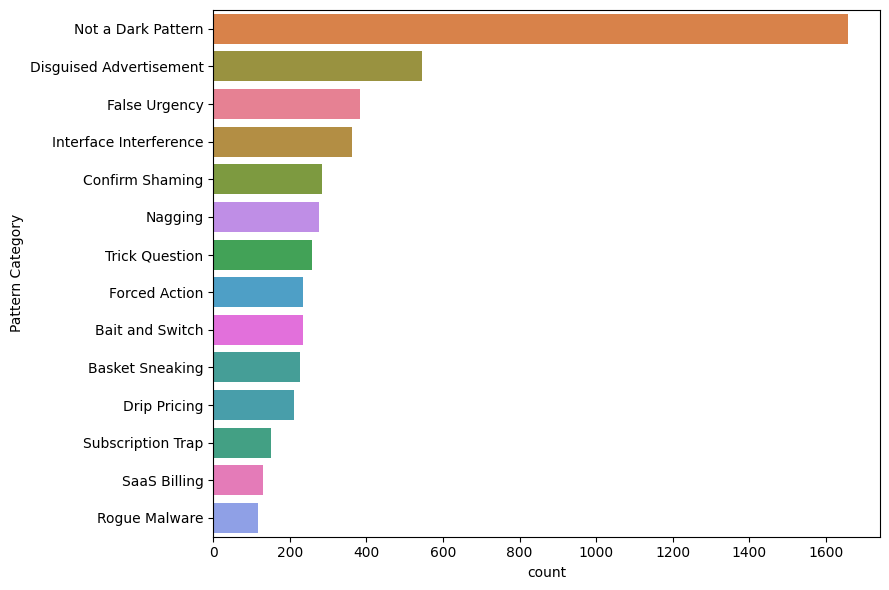

In [ ]:
# distribution after adding the collected examples
plt.figure(figsize=(9, 6))
sns.countplot(y='Pattern Category', data=df_processed, order=df_processed['Pattern Category'].value_counts().index, hue='Pattern Category')
plt.tight_layout()
plt.show()

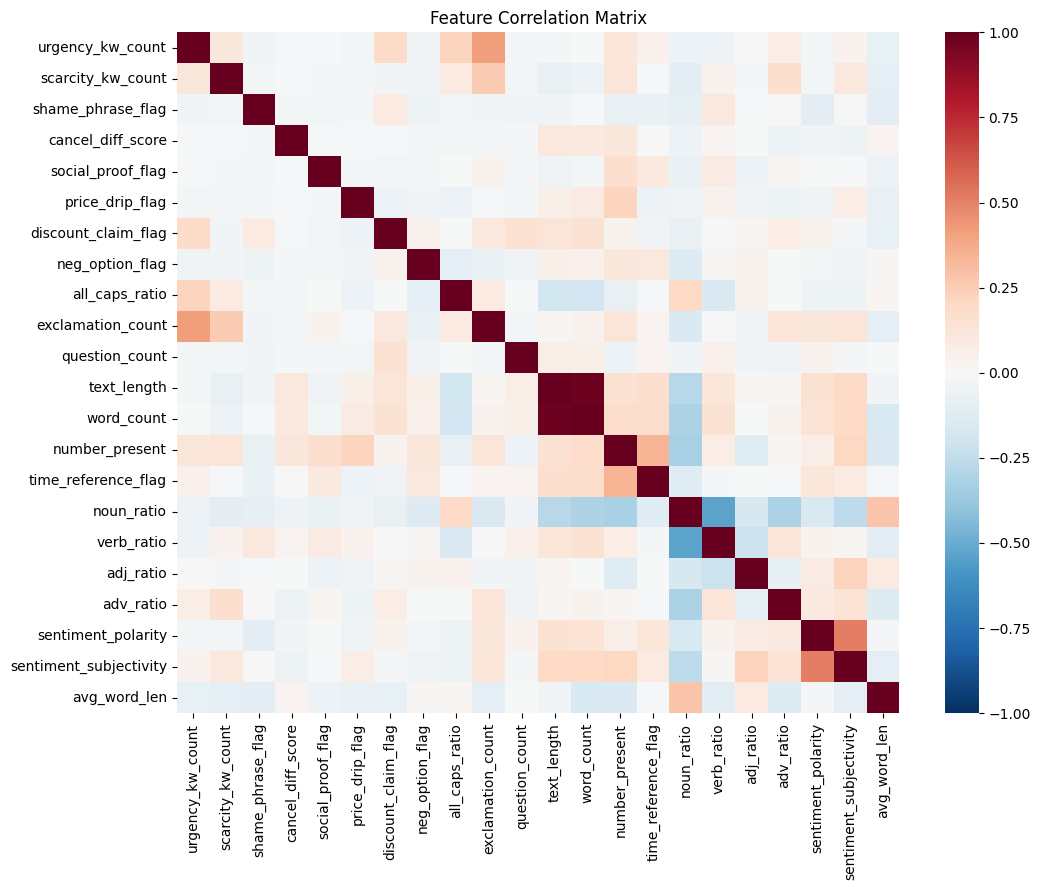

In [47]:
# correlation between the engineered numeric features
num_cols = df_features.columns.tolist()
plt.figure(figsize=(11, 9))
sns.heatmap(df_processed[num_cols].corr(), center=0,annot=False, cmap='RdBu_r', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

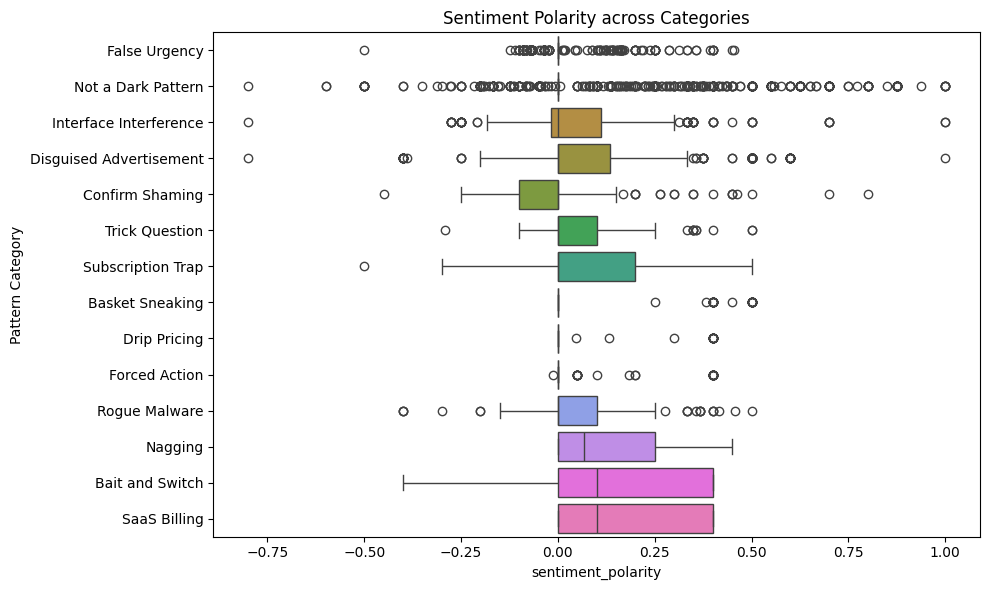

In [ ]:
# sentiment polarity by category (confirm-shaming should skew negative)
plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment_polarity', y='Pattern Category', data=df_processed, hue='Pattern Category')
plt.title('Sentiment Polarity across Categories')
plt.tight_layout()
plt.show()

In [49]:
# avg urgency-keyword count per category
df_processed.groupby('Pattern Category')['urgency_kw_count'].mean().sort_values(ascending=False)

Pattern Category
False Urgency              0.523560
Nagging                    0.072464
Subscription Trap          0.006667
Interface Interference     0.005540
Disguised Advertisement    0.003676
Bait and Switch            0.000000
Basket Sneaking            0.000000
Confirm Shaming            0.000000
Drip Pricing               0.000000
Forced Action              0.000000
Not a Dark Pattern         0.000000
Rogue Malware              0.000000
SaaS Billing               0.000000
Trick Question             0.000000
Name: urgency_kw_count, dtype: float64

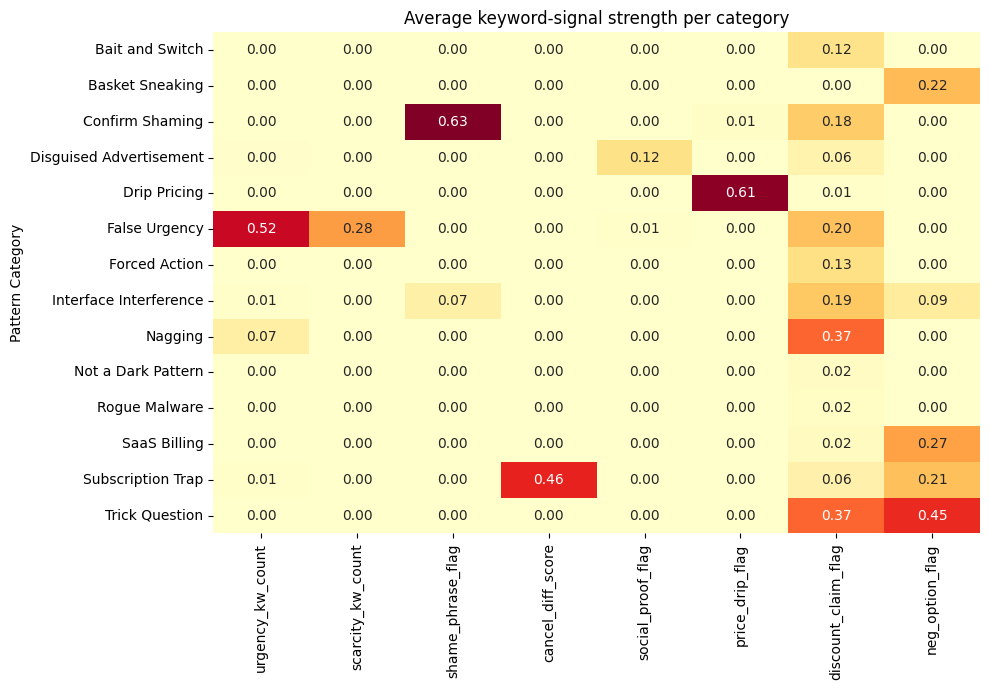

In [50]:
# does each category fire its own keyword family? (feature validation)
flag_cols = ['urgency_kw_count', 'scarcity_kw_count', 'shame_phrase_flag', 'cancel_diff_score',
             'social_proof_flag', 'price_drip_flag', 'discount_claim_flag', 'neg_option_flag']
flag_by_cat = df_processed.groupby('Pattern Category')[flag_cols].mean()
plt.figure(figsize=(10, 7))
sns.heatmap(flag_by_cat, cmap='YlOrRd', annot=True, fmt='.2f', cbar=False)
plt.title('Average keyword-signal strength per category')
plt.tight_layout()
plt.show()

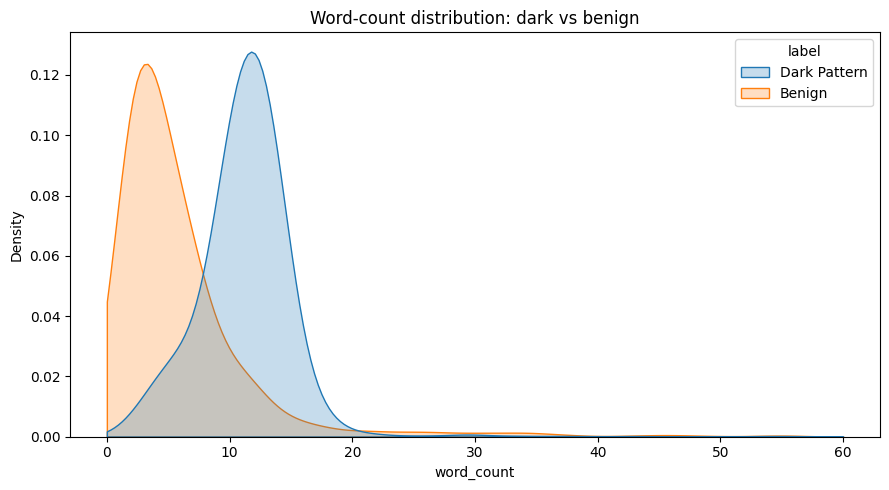

In [51]:
# dark patterns vs benign
group = df_processed['label'].map({0: 'Benign', 1: 'Dark Pattern'})
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df_processed, x='word_count', hue=group, fill=True, common_norm=False, clip=(0, 60))
plt.title('Word-count distribution: dark vs benign')
plt.tight_layout()
plt.show()

In [52]:
# coercive style: dark patterns shout more (! and CAPS) and are more subjective
df_processed.groupby(group)[['exclamation_count', 'all_caps_ratio', 'sentiment_subjectivity']].mean()

,exclamation_count,all_caps_ratio,sentiment_subjectivity
label,,,
Benign,0.043426,0.131499,0.156133
Dark Pattern,0.111666,0.078242,0.260796


## 9. Save the Processed Dataset

In [53]:
df[['page_id', 'text', 'label', 'Pattern Category']].to_csv('../data/processed/ccpa_dataset.tsv', sep='\t', index=False)
df_processed.to_csv('../data/processed/features.csv', index=False)

print("Saved ccpa_dataset.tsv and features.csv")
print("Final shape:", df_processed.shape)

Saved ccpa_dataset.tsv and features.csv
Final shape: (5061, 27)
